In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import f1_score
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam
import joblib
import pickle
import warnings
warnings.filterwarnings("ignore")


In [2]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [4]:
start_program = time.time()
photos_csv = r"D:\Dataset\photos_data.csv"
photos_folder = r"D:\Dataset\photos"
# Load dataset
df = pd.read_csv(photos_csv)

In [20]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


In [22]:
df=df[['photo_id','label']]

In [24]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


DATA PREPROCESSING

In [28]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


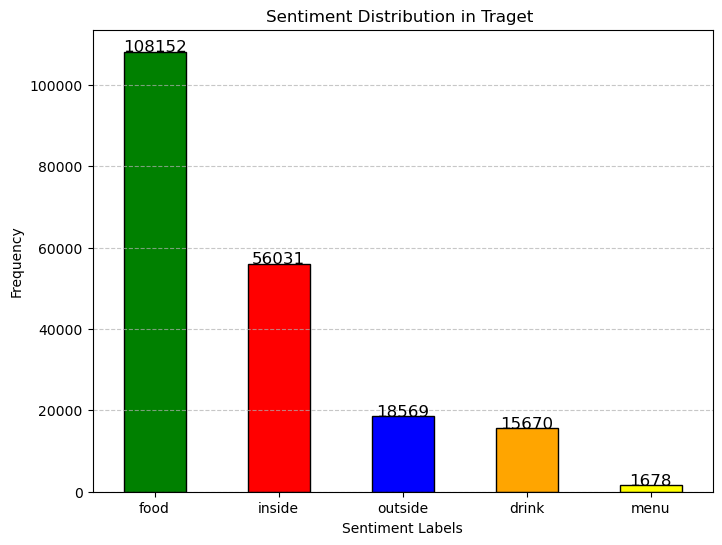

In [30]:
bar_plot(df['label'])

BALANCING THE DATASET

In [34]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
df_balanced

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
...,...,...
1495,b2Z_mH6elUbFfZ__rFmxWg,drink
1496,Hja-ujyebg1J0xyOzeaY_w,menu
1497,JLe7-8DzxieeiOHn-m1r5Q,outside
1498,FIw7ce992NJheBr9qEFHCA,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


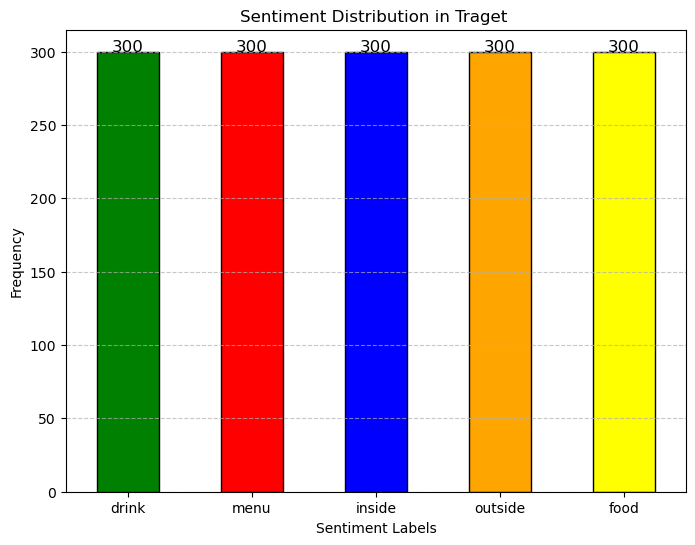

In [38]:
bar_plot(df_balanced['label'])

In [40]:
df = df_balanced

CONFIRMING THE COLUMN NAME

In [43]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [44]:
df.head(10)

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
5,4v5ns1DEc7DAz0r3xyrRqw,outside
6,bdtmWbdi6PRn_M1-aHYjcw,drink
7,t61K63S-DfSbufXgZpA_Ng,outside
8,pn4AVzlHlu4PhBpyDpb2wQ,menu
9,l_rMdwgrvjm2PyHyXBcBTw,food


In [47]:
# Get the first 10 records from the dictionary
first_10_records = dict(list(photo_id_to_path.items())[:10])

# Print them
print("First 10 records:", first_10_records)

First 10 records: {'--puCF1Lauwb3k6vrVVvfQ': 'D:\\Dataset\\photos\\--puCF1Lauwb3k6vrVVvfQ.jpg', '-10Ge63S6TdapDZV5ZGJLw': 'D:\\Dataset\\photos\\-10Ge63S6TdapDZV5ZGJLw.jpg', '-15xxjJWleNHNoApS8nXZA': 'D:\\Dataset\\photos\\-15xxjJWleNHNoApS8nXZA.jpg', '-3qJQmfAxo33Dp07QzkWtA': 'D:\\Dataset\\photos\\-3qJQmfAxo33Dp07QzkWtA.jpg', '-3yDzSGRk9m7z-N6bOH0Ag': 'D:\\Dataset\\photos\\-3yDzSGRk9m7z-N6bOH0Ag.jpg', '-5bUepz7K1gaHBD3LzApbQ': 'D:\\Dataset\\photos\\-5bUepz7K1gaHBD3LzApbQ.jpg', '-6buz7yJj7J-fAEBpzfPhw': 'D:\\Dataset\\photos\\-6buz7yJj7J-fAEBpzfPhw.jpg', '-BQqi2wtRzy3TjZj3ugjuw': 'D:\\Dataset\\photos\\-BQqi2wtRzy3TjZj3ugjuw.jpg', '-BW8LZAgLYSbC9Hka7v5yA': 'D:\\Dataset\\photos\\-BW8LZAgLYSbC9Hka7v5yA.jpg', '-BzkuAu2ShaH4qd1vp6xMg': 'D:\\Dataset\\photos\\-BzkuAu2ShaH4qd1vp6xMg.jpg'}


RESIZING THE IMAGE

In [50]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

Error occurred: cannot identify image file <_io.BytesIO object at 0x000002821005BB50>
Image path: D:\Dataset\photos\l_rMdwgrvjm2PyHyXBcBTw.jpg
1393
[[[[0.9529412  0.9529412  0.9607843 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.69411767 0.8117647  0.9137255 ]
   [0.7607843  0.8627451  0.9529412 ]
   [0.78431374 0.88235295 0.96862745]]

  [[0.95686275 0.95686275 0.9647059 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.8509804  0.9372549  1.        ]
   [0.8745098  0.95686275 1.        ]
   [0.8862745  0.9607843  1.        ]]

  [[0.9607843  0.9607843  0.96862745]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.89411765 0.95686275 1.        ]
   [0.8980392  0.9529412  0.99607843]
   [0.89411765 0.9411765  0.9882353 ]]

  ...

  [[0.5137255  0.41960785 0.37254903]
   [0.49803922 0.39607844 0.3372549 ]
   [0.40784314 0.30980393 0.22352941]
   ...
   [0.4274509

MAPPING THE LABELS

In [52]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [54]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

Shape of the image array:  (1393, 150528)
Shape of the target array:  (1393,)


Making functions for evaluations

In [56]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Step 2: Convert the confusion matrix to a DataFrame for better visualization
    cm_df = pd.DataFrame(cm, index=[reverse_label_mapping[i] for i in range(len(cm))], 
                         columns=[reverse_label_mapping[i] for i in range(len(cm))])
    
    print(cm_df)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", xticklabels=cm_df.columns, yticklabels=cm_df.columns)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [58]:
def plot_roc_curve(y_true, y_pred_bin):
     # Initialize LabelBinarizer
    lb = LabelBinarizer()

    # Binarize the true labels (one-hot encoding)
    y_true_bin = lb.fit_transform(y_true)   
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_true_bin.shape[1]):  # Iterate through all classes
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves in one plot
    plt.figure(figsize=(10, 8))
    
    # Plot ROC for each class
    for i in range(y_true_bin.shape[1]):
        label = lb.classes_[i]
        plt.plot(fpr[i], tpr[i], label=f'{reverse_label_mapping[label]} (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Labeling and Title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

    # Print AUC values for each class
    for i in range(y_true_bin.shape[1]):
        print(f'AUC for class {lb.classes_[i]}: {roc_auc[i]:.2f}')


SPLLITING THE DATA

In [61]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)

print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1114, 150528)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 150528)
Shape of y_test:  (279,)


class_count :  1    228
4    228
0    221
3    220
2    217
Name: count, dtype: int64


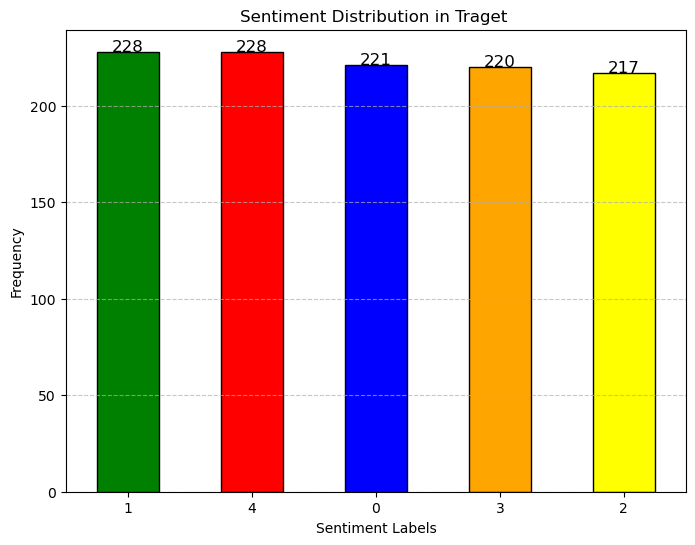

In [63]:
bar_plot(y_train)

In [65]:
# # Assuming X is your feature matrix and y is your target labels
# smote = SMOTE(random_state=42)
# x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# print("Shape of x_resampled: ",x_resampled.shape)
# print("Shape of y_resampled: ",y_resampled.shape)

In [67]:
# print("\nx_train : ", x_train)
# print("\ny_train : ", y_train)
# print("\nx_resampled : ", x_resampled)
# print("\ny_resampled : ", y_resampled)

In [69]:
# bar_plot(y_resampled)

BUILDING MODEL FUNCTIONS

In [71]:
def model_result(model, x_train, y_train, x_test, y_test):
    # Evaluate on Training Data
    y_train_pred = model.predict(x_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Evaluate on Testing Data
    y_test_pred = model.predict(x_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Classification report for train and test
#     train_classification_report = classification_report(y_train, y_train_pred)
#     test_classification_report = classification_report(y_test, y_test_pred)
    
    # Get predicted probabilities instead of class predictions
    y_pred_proba_test = model.predict_proba(x_test)
    y_pred_proba_train = model.predict_proba(x_train)

    # Confusion Matrix for train and test
    train_conf_matrix = confusion_matrix(y_train, y_train_pred)
    test_conf_matrix = confusion_matrix(y_test, y_test_pred)

    # Print results for train data
    print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Train:\n ", train_conf_matrix)
    # F1 scores for train data
    f1_train = f1_score(y_train, y_train_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_train):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTraining Classification Report:")
#     print(train_classification_report)
    plot_confusion_matrix(y_train, y_train_pred)
    plot_roc_curve(y_train, y_pred_proba_train)

    # Print results for test data
    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Test:\n ", test_conf_matrix)
    # F1 scores for test data
    f1_test = f1_score(y_test, y_test_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_test):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTest Classification Report:")
#     print(test_classification_report)
    plot_confusion_matrix(y_test, y_test_pred)
    plot_roc_curve(y_test, y_pred_proba_test)

BUILDING SVM MODEL

In [151]:
from sklearn.preprocessing import StandardScaler

# Standardize features to have zero mean and unit variance
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)  # Use same scaler for test data


In [153]:
from sklearn.decomposition import PCA

# Reduce to 50 principal components (adjust as needed)
pca = PCA(n_components=50)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)


In [157]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


Training Time: 0.59 seconds

Training Accuracy: 87.07%

Confusion matrix Train:
  [[196  10   4   5   6]
 [  3 209   5   4   7]
 [  0  21 190   2   4]
 [ 10  21   7 177   5]
 [  1  22   3   4 198]]

F1 Scores for each class:
food: 0.9095
inside: 0.8180
outside: 0.8920
drink: 0.8592
menu: 0.8839
         food  inside  outside  drink  menu
food      196      10        4      5     6
inside      3     209        5      4     7
outside     0      21      190      2     4
drink      10      21        7    177     5
menu        1      22        3      4   198


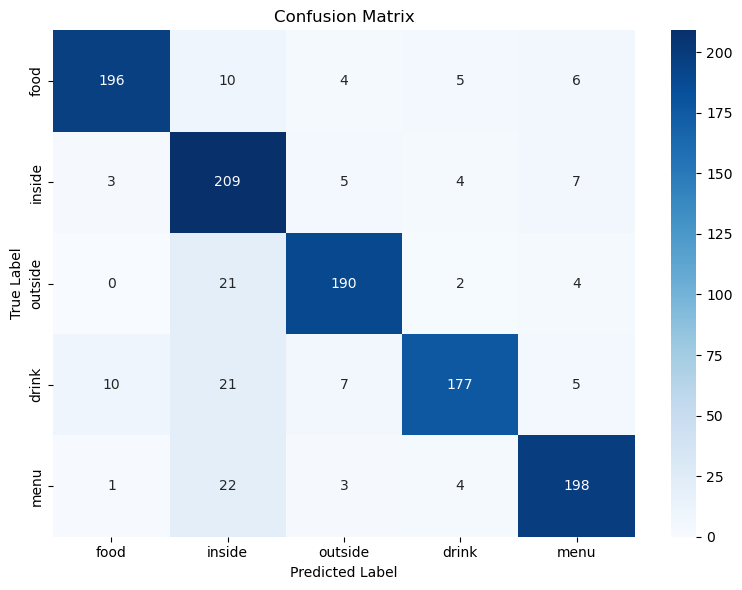

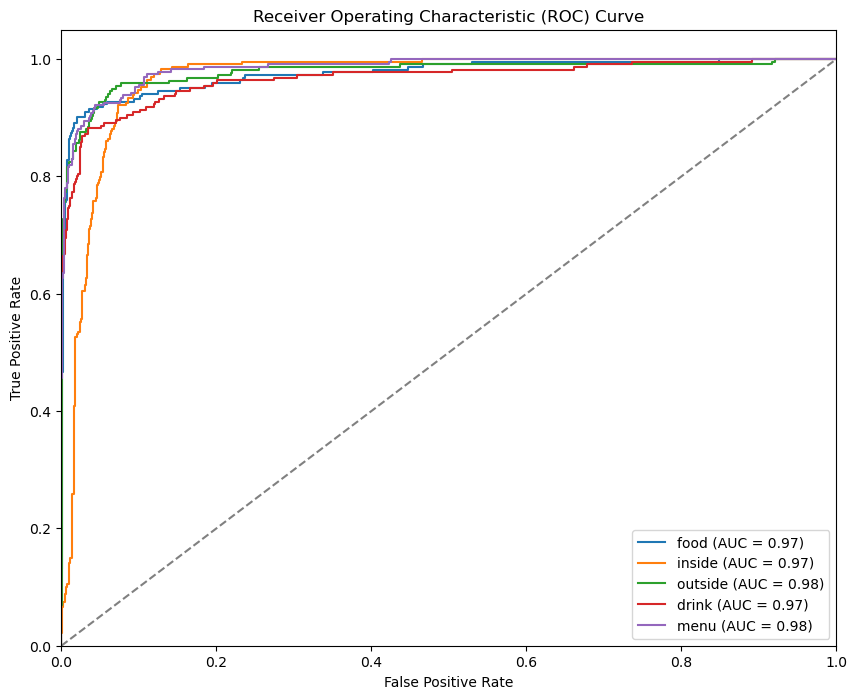

AUC for class 0: 0.97
AUC for class 1: 0.97
AUC for class 2: 0.98
AUC for class 3: 0.97
AUC for class 4: 0.98

Test Accuracy: 52.33%

Confusion matrix Test:
  [[28  7  2 11  6]
 [ 2 32  5  7  6]
 [ 3  9 33  8  5]
 [15  8  7 20  8]
 [ 3 18  1  2 33]]

F1 Scores for each class:
food: 0.5333
inside: 0.5079
outside: 0.6226
drink: 0.3774
menu: 0.5739
         food  inside  outside  drink  menu
food       28       7        2     11     6
inside      2      32        5      7     6
outside     3       9       33      8     5
drink      15       8        7     20     8
menu        3      18        1      2    33


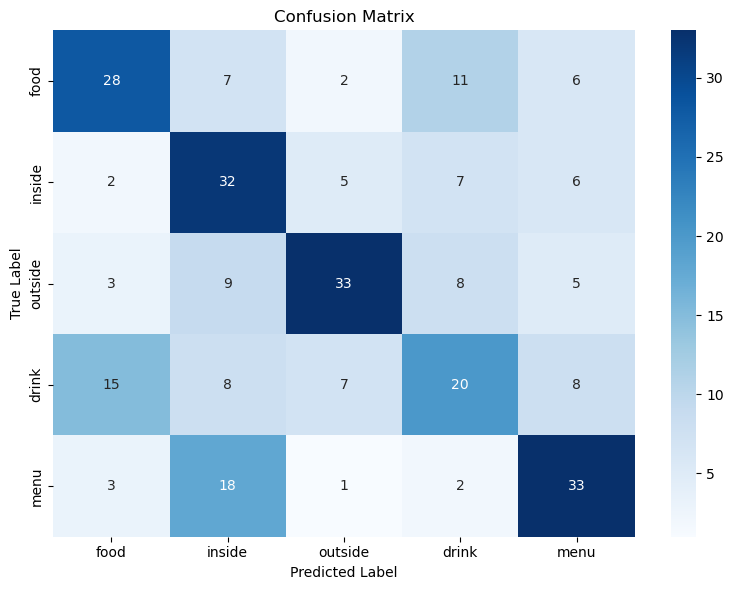

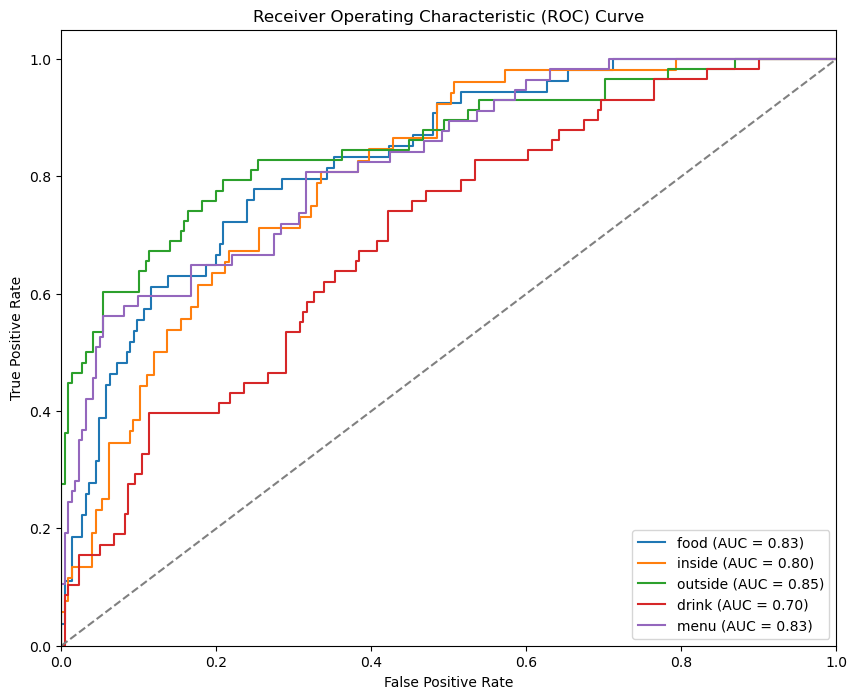

AUC for class 0: 0.83
AUC for class 1: 0.80
AUC for class 2: 0.85
AUC for class 3: 0.70
AUC for class 4: 0.83
Model Saved Successfully


In [167]:
# Create the SVM model with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

start_time = time.time()
svm_model.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

model_result(svm_model, x_train, y_train, x_test, y_test)
save_model(svm_model, "D:\Models", "svm_photo")
print("Model Saved Successfully")

TUNING SVM MODEL

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Training Time: 2.47 seconds
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.4704

Training Accuracy: 97.04%

Confusion matrix Train:
  [[219   0   1   0   1]
 [  0 225   0   0   3]
 [  1   4 210   0   2]
 [  3  11   0 206   0]
 [  0   6   1   0 221]]

F1 Scores for each class:
food: 0.9865
inside: 0.9494
outside: 0.9790
drink: 0.9671
menu: 0.9714
         food  inside  outside  drink  menu
food      219       0        1      0     1
inside      0     225        0      0     3
outside     1       4      210      0     2
drink       3      11        0    206     0
menu        0       6        1      0   221


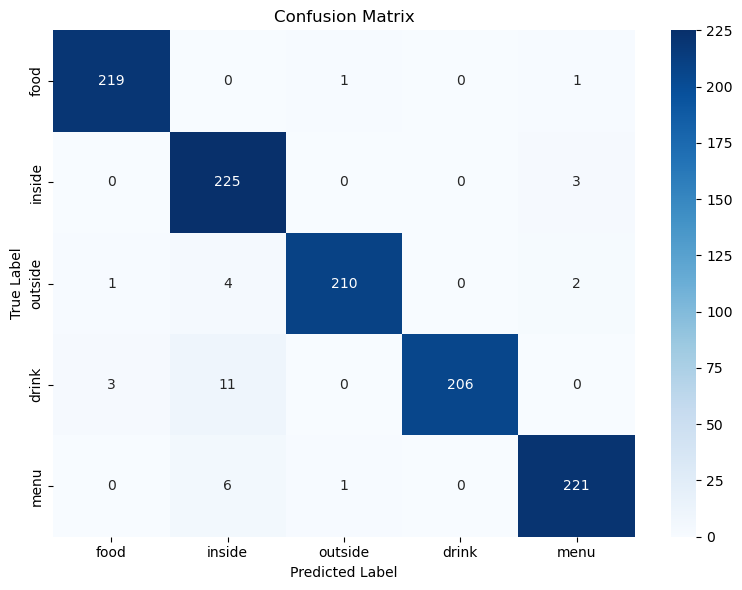

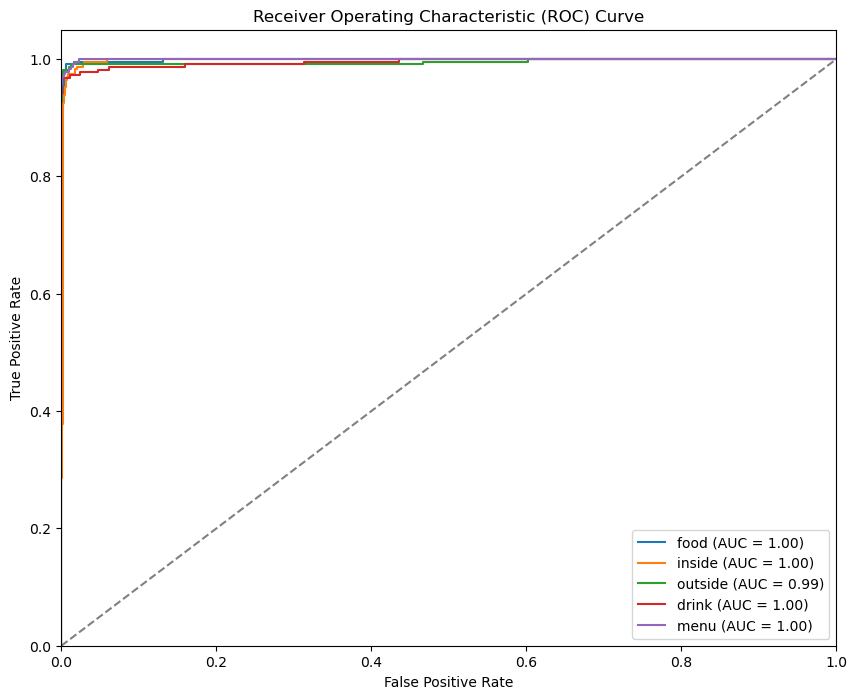

AUC for class 0: 1.00
AUC for class 1: 1.00
AUC for class 2: 0.99
AUC for class 3: 1.00
AUC for class 4: 1.00

Test Accuracy: 48.39%

Confusion matrix Test:
  [[26  8  4 10  6]
 [ 2 28  7  8  7]
 [ 3 11 30  9  5]
 [13  8 11 18  8]
 [ 2 14  1  7 33]]

F1 Scores for each class:
food: 0.5200
inside: 0.4628
outside: 0.5405
drink: 0.3273
menu: 0.5690
         food  inside  outside  drink  menu
food       26       8        4     10     6
inside      2      28        7      8     7
outside     3      11       30      9     5
drink      13       8       11     18     8
menu        2      14        1      7    33


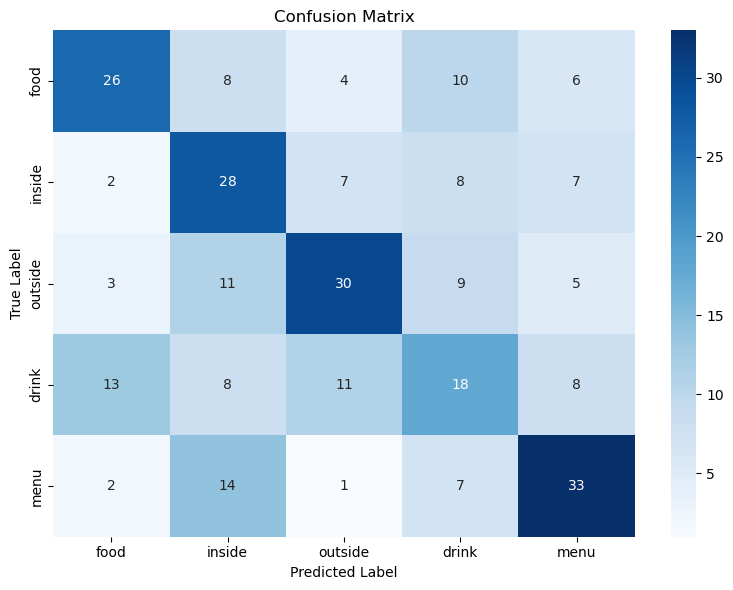

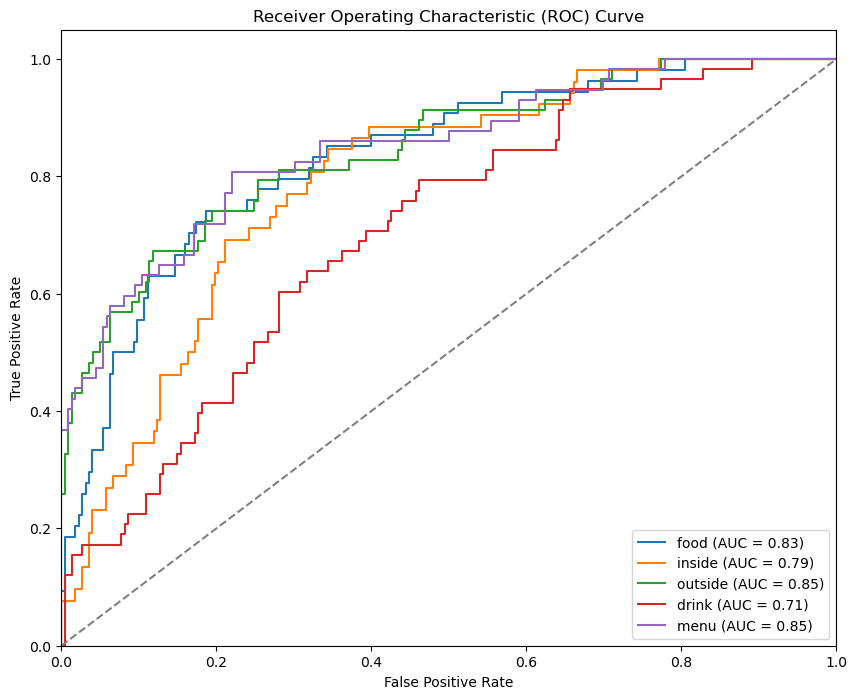

AUC for class 0: 0.83
AUC for class 1: 0.79
AUC for class 2: 0.85
AUC for class 3: 0.71
AUC for class 4: 0.85


In [174]:
 param_grid = {
    'C': [0.1, 10],  # Test values for C
     'gamma': [0.01, 0.1],  # Test values for gamma
    'kernel': ['rbf']
}
 # Initialize GridSearchCV
 grid_search = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

 start_time = time.time()
 # Fit the model to the training data
 grid_search.fit(x_train, y_train)
 end_time = time.time()

 # Calculate training time
 training_time = end_time - start_time
 print(f"Training Time: {training_time:.2f} seconds")

# Display the best parameters from GridSearch
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Get the best model after GridSearch
best_svm = grid_search.best_estimator_

model_result(best_svm, x_train, y_train, x_test, y_test)